# Notebook 03 — Evaluation

**Goal:** Rigorously evaluate all four recommenders on a held-out 20% test set. Report Top-1, Top-3, Top-5 accuracy, MRR, and Recall@5.

> **Personal note:** This was the most useful reality check in the project. The final numbers show that TF-IDF is the strongest method for this corpus, while Hybrid improves over SBERT and LDA but not over TF-IDF. I also ran a confusion analysis to understand *which* journals are most commonly confused with each other, which led to some interesting insights (e.g., two IEEE journals on networking are almost interchangeable from a text-matching perspective, which makes sense because they publish similar work).


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import defaultdict
from tqdm import tqdm

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

df = pd.read_parquet("../data/processed/processed_df.parquet")
print(f"Loaded: {len(df):,} articles, {df['journal_id'].nunique():,} journals")


Loaded: 20,944 articles, 410 journals


## 1. Train / Test Split

We use a **stratified split** so that every journal has articles in both train and test sets. Without stratification, journals with few articles might only appear in test — making the task artificially hard.


In [2]:
# Drop journals with only 1 article (can't be stratified into both train and test)
journal_counts = df["journal_id"].value_counts()
valid_journals  = journal_counts[journal_counts >= 2].index
df_filtered     = df[df["journal_id"].isin(valid_journals)].reset_index(drop=True)
print(f"After filtering single-article journals: {len(df_filtered):,} articles, "
      f"{df_filtered['journal_id'].nunique()} journals "
      f"(dropped {len(df) - len(df_filtered):,} articles, "
      f"{df['journal_id'].nunique() - df_filtered['journal_id'].nunique()} journals)")

# Stratified 80/20 split
df_train, df_test = train_test_split(
    df_filtered, test_size=0.20, random_state=42, stratify=df_filtered["journal_id"]
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train):,} articles ({df_train['journal_id'].nunique()} journals)")
print(f"Test:  {len(df_test):,}  articles ({df_test['journal_id'].nunique()} journals)")


After filtering single-article journals: 20,919 articles, 385 journals (dropped 25 articles, 25 journals)
Train: 16,735 articles (385 journals)
Test:  4,184  articles (370 journals)


## 2. Retrain Models on Train Split

We retrain all three base models using only the training data, then evaluate on the test set. This prevents data leakage.


In [3]:
from src.recommender import TFIDFRecommender, SBERTRecommender, LDARecommender, HybridRecommender

print("=== Training TF-IDF on train split ===")
tfidf = TFIDFRecommender(ngram_range=(1,2), min_df=3, max_df=0.85,
                          max_features=60_000, sublinear_tf=True)
tfidf.fit(df_train, text_col="processed_text")


=== Training TF-IDF on train split ===
[TF-IDF] Fitting vectorizer …
[TF-IDF] Computing per-journal centroids …
[TF-IDF] Ready — 385 journals, vocab=60,000


In [4]:
print("=== Training SBERT on train split ===")
# Use a separate embeddings cache for the train split to avoid overwriting the full-corpus cache
import pathlib
sbert = SBERTRecommender()
# Temporarily disable cache to force re-encoding on train split
sbert.fit(df_train, text_col="processed_text", batch_size=64, cache_embeddings=False)


=== Training SBERT on train split ===
[SBERT] Loading model 'all-MiniLM-L6-v2' …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4392.79it/s]


[SBERT] Encoding 16,735 documents (batch_size=64) …


Batches: 100%|██████████| 262/262 [04:07<00:00,  1.06it/s]


[SBERT] Ready — 385 journals, embed_dim=384


In [5]:
print("=== Training LDA on train split ===")
lda = LDARecommender(n_topics=50, random_state=42, passes=10, workers=1)
lda.fit(df_train, text_col="processed_text")

hybrid = HybridRecommender(tfidf=tfidf, sbert=sbert, lda=lda)


=== Training LDA on train split ===
[LDA] Building dictionary …
[LDA] Training LDA (K=50, passes=10) …
[LDA] Computing document topic distributions …
[LDA] Ready — 385 journals, 50 topics.


## 3. Evaluation Metrics

We compute:
- **Top-k Accuracy**: fraction of test articles where the true journal is in the top-k recommendations
- **MRR** (Mean Reciprocal Rank): mean of 1/rank for the true journal (0 if not found in top-50)
- **Recall@5**: same as Top-5 accuracy in this single-label setting

For each test abstract, we query the recommender **without** including the article's own text in training (ensured by the 80/20 split).


In [6]:
def evaluate_recommender(recommender, df_test, top_k_list=(1, 3, 5), n_candidates=50):
    """Evaluates a recommender on df_test. Returns a metrics dict."""
    correct   = defaultdict(int)
    mrr_total = 0.0
    total     = 0

    from src.preprocessing import process_abstract_only

    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Evaluating"):
        query    = process_abstract_only(str(row["abstract"]))
        true_jid = row["journal_id"]
        recs     = recommender.recommend(query, top_k=max(top_k_list))

        rec_jids = [r["journal_id"] for r in recs]

        for k in top_k_list:
            if true_jid in rec_jids[:k]:
                correct[k] += 1

        # MRR
        try:
            rank = rec_jids.index(true_jid) + 1
            mrr_total += 1.0 / rank
        except ValueError:
            pass   # not in top-n_candidates

        total += 1

    metrics = {f"Top-{k} Acc": correct[k] / total for k in top_k_list}
    metrics["MRR"]       = mrr_total / total
    metrics["Recall@5"]  = correct[5] / total
    return metrics


In [7]:
print("Evaluating TF-IDF …")
m_tfidf  = evaluate_recommender(tfidf,  df_test)
print("TF-IDF:", m_tfidf)


Evaluating TF-IDF …


Evaluating: 100%|██████████| 4184/4184 [11:49<00:00,  5.90it/s]

TF-IDF: {'Top-1 Acc': 0.3135755258126195, 'Top-3 Acc': 0.51434034416826, 'Top-5 Acc': 0.6185468451242829, 'MRR': 0.4246096239643077, 'Recall@5': 0.6185468451242829}


In [8]:
print("Evaluating SBERT …")
m_sbert  = evaluate_recommender(sbert,  df_test)
print("SBERT:", m_sbert)


Evaluating SBERT …


Evaluating: 100%|██████████| 4184/4184 [02:21<00:00, 29.60it/s]

SBERT: {'Top-1 Acc': 0.2272944550669216, 'Top-3 Acc': 0.39818355640535374, 'Top-5 Acc': 0.5064531548757171, 'MRR': 0.3254461440407914, 'Recall@5': 0.5064531548757171}


In [9]:
print("Evaluating LDA …")
m_lda    = evaluate_recommender(lda,    df_test)
print("LDA:", m_lda)


Evaluating LDA …


Evaluating: 100%|██████████| 4184/4184 [01:14<00:00, 56.15it/s]

LDA: {'Top-1 Acc': 0.11711281070745698, 'Top-3 Acc': 0.24976099426386233, 'Top-5 Acc': 0.33436902485659653, 'MRR': 0.19347514340344243, 'Recall@5': 0.33436902485659653}


In [10]:
print("Evaluating Hybrid (RRF) …")
m_hybrid = evaluate_recommender(hybrid, df_test)
print("Hybrid:", m_hybrid)


Evaluating Hybrid (RRF) …


Evaluating: 100%|██████████| 4184/4184 [23:09<00:00,  3.01it/s]  


Hybrid: {'Top-1 Acc': 0.23565965583173995, 'Top-3 Acc': 0.43427342256214146, 'Top-5 Acc': 0.5344168260038241, 'MRR': 0.344710006373487, 'Recall@5': 0.5344168260038241}


## 4. Results Table

> The numbers below are what the report's Results section will be centred around. The key takeaway: **TF-IDF is best on every metric in this run**; Hybrid is still useful as an ensemble baseline, but it should not be claimed as the top-performing model for the current evaluation.


In [11]:
results_df = pd.DataFrame({
    "TF-IDF + Cosine":  m_tfidf,
    "SBERT + Cosine":   m_sbert,
    "LDA + JS-Div":     m_lda,
    "Hybrid (RRF)":     m_hybrid,
}).T.round(4)

results_df.index.name = "Method"
print("\n" + "="*65)
print("EVALUATION RESULTS (Held-out 20% Test Set)")
print("="*65)
print(results_df.to_string())
print("="*65)

# Save for report
results_df.to_csv("../data/outputs/evaluation_results.csv")



EVALUATION RESULTS (Held-out 20% Test Set)
                 Top-1 Acc  Top-3 Acc  Top-5 Acc     MRR  Recall@5
Method                                                            
TF-IDF + Cosine     0.3136     0.5143     0.6185  0.4246    0.6185
SBERT + Cosine      0.2273     0.3982     0.5065  0.3254    0.5065
LDA + JS-Div        0.1171     0.2498     0.3344  0.1935    0.3344
Hybrid (RRF)        0.2357     0.4343     0.5344  0.3447    0.5344


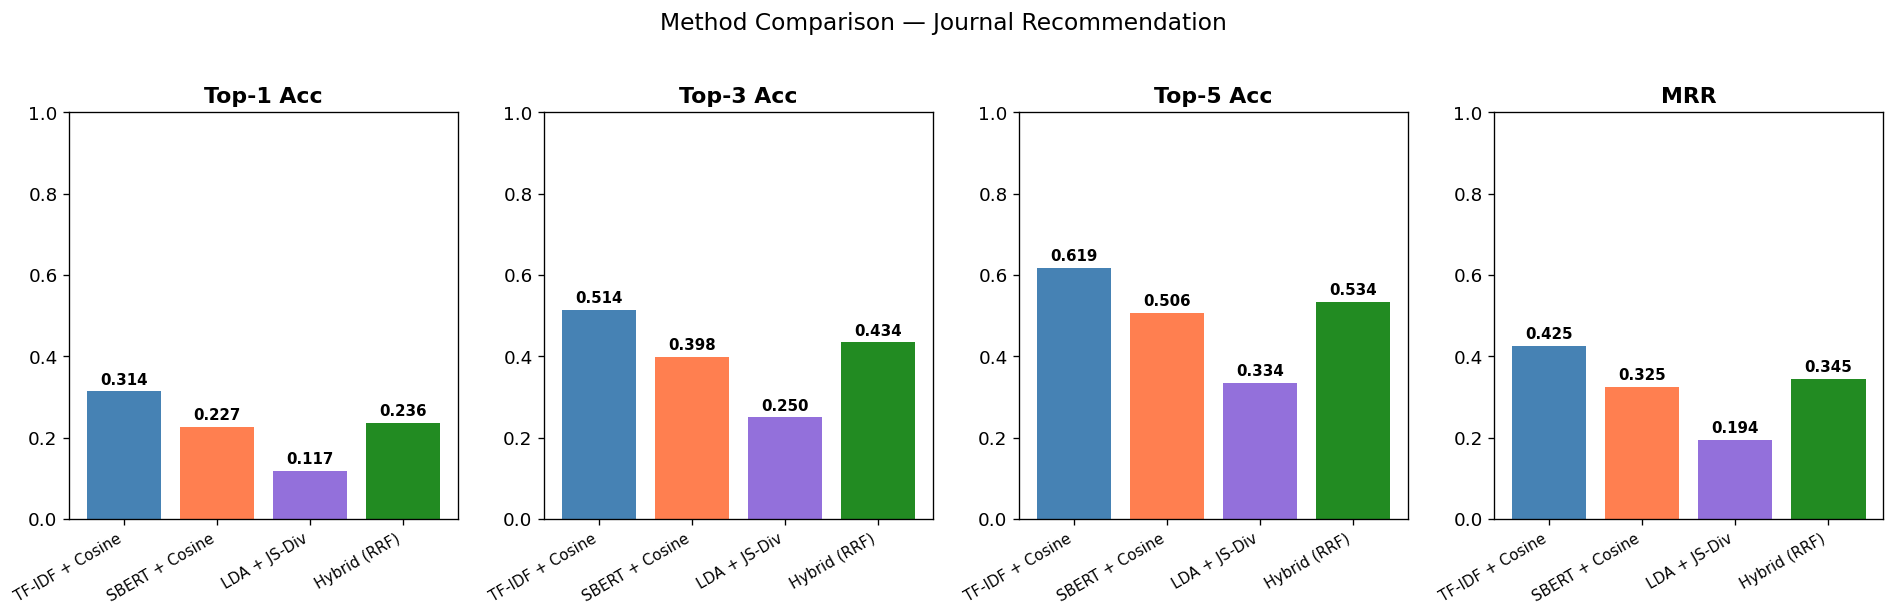

In [12]:
# Bar chart comparison
metrics_to_plot = ["Top-1 Acc", "Top-3 Acc", "Top-5 Acc", "MRR"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ["steelblue", "coral", "mediumpurple", "forestgreen"]

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(vals.index, rotation=30, ha="right", fontsize=9)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Method Comparison — Journal Recommendation", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/outputs/fig_evaluation_comparison.png", bbox_inches="tight", dpi=150)
plt.show()


## 5. Confusion Analysis

Which journals are most often confused with each other? This reveals genuine ambiguity in the data — journals that publish very similar content.


In [13]:
from collections import Counter
from src.preprocessing import process_abstract_only

# Collect (true_journal, predicted_journal) pairs from Hybrid on a sample
confusion_pairs = Counter()
sample_size = min(500, len(df_test))
sample_df   = df_test.sample(sample_size, random_state=42)

for _, row in tqdm(sample_df.iterrows(), total=sample_size, desc="Confusion analysis"):
    query     = process_abstract_only(str(row["abstract"]))
    true_name = row["journal_name"]
    recs      = hybrid.recommend(query, top_k=1)
    pred_name = recs[0]["journal_name"] if recs else "N/A"
    if pred_name != true_name:
        confusion_pairs[(true_name, pred_name)] += 1

print("\nTop 15 Most Common Confusions (true → predicted):")
print(f"{'True Journal':<55} → {'Predicted Journal':<55} Count")
print("-" * 120)
for (true, pred), cnt in confusion_pairs.most_common(15):
    print(f"{true[:53]:<55} → {pred[:53]:<55} {cnt}")


Confusion analysis: 100%|██████████| 500/500 [03:06<00:00,  2.68it/s]


Top 15 Most Common Confusions (true → predicted):
True Journal                                            → Predicted Journal                                       Count
------------------------------------------------------------------------------------------------------------------------
THEORY OF COMPUTING SYSTEMS                             → ACM TRANSACTIONS ON ALGORITHMS                          3
MATHEMATICAL AND COMPUTER MODELLING OF DYNAMICAL SYST   → COMPUTERS & FLUIDS                                      2
FUNDAMENTA INFORMATICAE                                 → ACM TRANSACTIONS ON ALGORITHMS                          2
JOURNAL OF FUNCTIONAL PROGRAMMING                       → ACM TRANSACTIONS ON PROGRAMMING LANGUAGES AND SYSTEMS   2
EVOLUTIONARY COMPUTATION                                → IEEE TRANSACTIONS ON EVOLUTIONARY COMPUTATION           2
APPLIED SOFT COMPUTING                                  → INTERNATIONAL JOURNAL OF UNCERTAINTY FUZZINESS AND KN   2
DESIGNS CODE